In [10]:
# importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Part 1: Data Generator 

In [3]:
def generate_noisy_dataset(feature_functions,true_function,x_range,n_samples,epsilon,seed=20):
    
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_range[0], x_range[1], size=n_samples)
    noise = rng.uniform(-epsilon, epsilon, size=n_samples)
    y = true_function(x) + noise
    data={"x" : x}
    feature_values = []
    for func in feature_functions:
        feature_values.append(func(x))
    for i, values in enumerate(feature_values, start=1):
        data[f"f_{i}(x)"] = values 
    data["y"]=y
    df=pd.DataFrame(data)
    return df
    

### Part 2 :- Linear Regression function creation

In [5]:
def linear_fit(training_data):
    X_train,Y_train=training_data.iloc[:,:-1],training_data.iloc[:,-1]
    X_train = np.insert(X_train, 0, 1, axis=1)
    beta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ Y_train
    return beta
    

In [6]:
def linear_predict(weight,test_data):
    X_test= test_data.iloc[:,:-1]
    X_test = np.insert(X_test ,0, 1, axis=1)
    Y_pred = X_test @ weight
    return Y_pred
    

In [7]:
def linear_evaluate(predictions,true_outputs):
    n= len(predictions)
    RMSE= np.sqrt(np.sum((predictions-true_outputs)**2)/n)
    return RMSE

### Question 3 :-

In [8]:
# Define the two true functions

def linear_function(x):
    return 2 * x + 1


def cubic_function(x):
    return 0.5 * x**3 - x**2 + x

Linear Function | Noise = 0.01
Weights: [0.99985728 2.00021643]
Train RMSE: 0.005947962284496113
Test RMSE: 0.005722706027523744


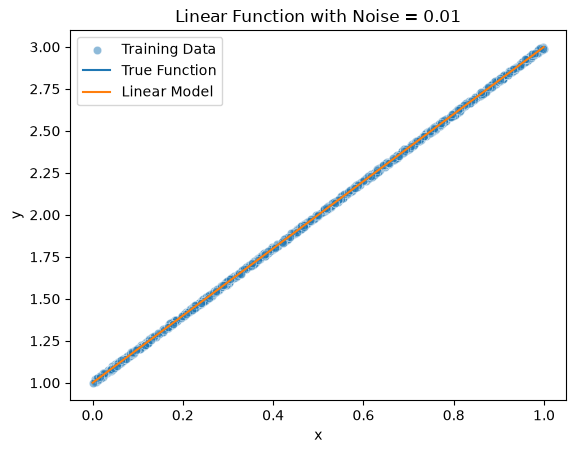

Linear Function | Noise = 0.1
Weights: [0.99857284 2.00216426]
Train RMSE: 0.05947962284496111
Test RMSE: 0.057227060275238384


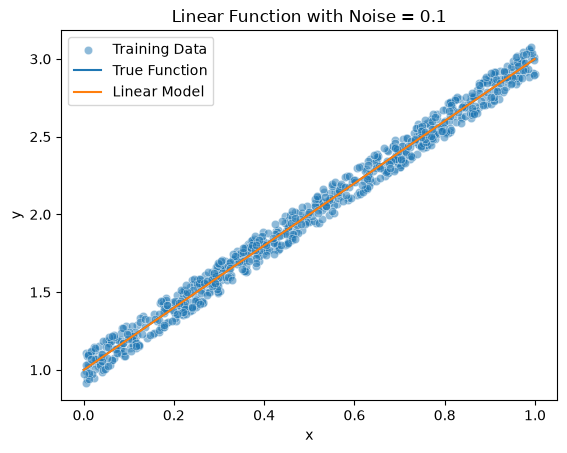

Cubic Function | Noise = 0.01
Weights: [0.06644583 0.44987209]
Train RMSE: 0.022120787939890942
Test RMSE: 0.021416768852763723


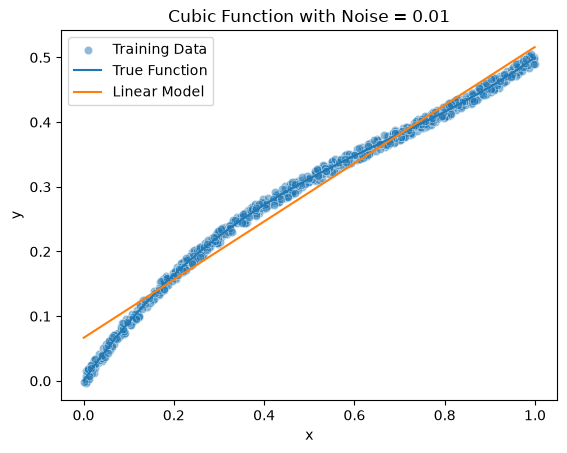

Cubic Function | Noise = 0.1
Weights: [0.06516139 0.45181992]
Train RMSE: 0.0630504504301626
Test RMSE: 0.05845382418229113


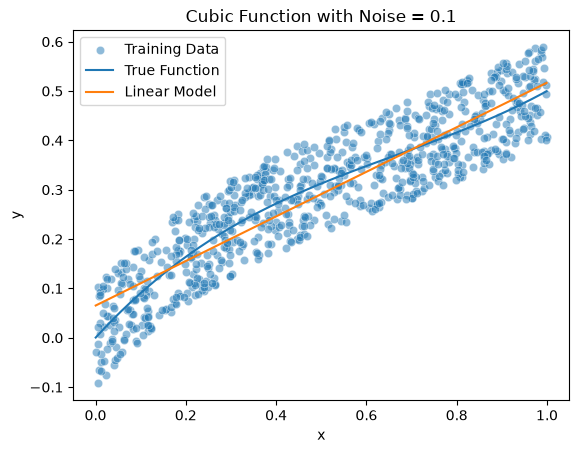

In [66]:
# Question 3 experiment combinations

experiments = [
    ("Linear", linear_function, 0.01),
    ("Linear", linear_function, 0.1),
    ("Cubic", cubic_function, 0.01),
    ("Cubic", cubic_function, 0.1)
]

# Save learned models separately
q3_models = {}

# Save complete experiment results
q3_results = {}

for function_name, true_function, epsilon in experiments:

    # Generate the dataset
    dataset = generate_noisy_dataset(
        feature_functions=[],
        true_function=true_function,
        x_range=(0, 1),
        n_samples=1000,
        epsilon=epsilon,
        seed=20
    )

    # Split into 80% training and 20% testing
    train_data, test_data = train_test_split(
        dataset,
        test_size=0.2,
        random_state=42
    )

    # Train the linear regression model
    beta = linear_fit(train_data)

    # Save the learned model weights
    q3_models[(function_name, epsilon)] = beta.copy()

    # Predict on the train_data
    train_predictions = linear_predict(beta, train_data)

    train_rmse = linear_evaluate(
    train_predictions,
    train_data.iloc[:, -1]
    )

    
    #Predict on test data
    test_predictions = linear_predict(beta, test_data)

    test_rmse = linear_evaluate(
    test_predictions,
    test_data.iloc[:, -1]
    )

    # Save all results for this experiment
    q3_results[(function_name, epsilon)] = {
    "dataset": dataset.copy(),
    "train_data": train_data.copy(),
    "test_data": test_data.copy(),
    "beta": beta.copy(),
    "train_predictions": train_predictions.copy(),
    "test_predictions": test_predictions.copy(),
    "train_rmse": train_rmse,
    "test_rmse": test_rmse
}

    # Print results
    print(f"{function_name} Function | Noise = {epsilon}")
    print("Weights:", beta)
    print("Train RMSE:", train_rmse)
    print("Test RMSE:", test_rmse)

    # Sort training x-values for plotting
    x_plot = np.sort(
        train_data["x"].to_numpy()
    )

    # True function values
    y_true_plot = true_function(x_plot)

    # Learned linear model
    y_model_plot = (
        beta[0]
        + beta[1] * x_plot
    )

    # Plot noisy training data
    sns.scatterplot(
        data=train_data,
        x="x",
        y="y",
        label="Training Data",
        alpha=0.5
    )

    # Plot true function
    plt.plot(
        x_plot,
        y_true_plot,
        label="True Function"
    )

    # Plot learned linear model
    plt.plot(
        x_plot,
        y_model_plot,
        label="Linear Model"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        f"{function_name} Function with Noise = {epsilon}"
    )
    plt.legend()
    plt.show()

**Interpretation for Linear function plot:-**
For the linear true function, the model performs very well for both noise levels. With noise = 0.01, the training points are tightly clustered around the blue true-function line, and the orange line that shows learned linear model almost completely overlaps with it. When the noise is increased to 0.1, the training points becomes more spread out around the true function but the learned model still remains very close to the true line. The test RMSE increases from about 0.0057 to 0.0572, showing that higher noise increases prediction error even though the underlying linear relationship is still learned correctly.

**Interpretation of cubic function plot with noise level 0.01:-**
The light blue points represent the noisy training data generated from the cubic true function with a noise level of 0.01. The blue line shows the actual cubic function, the orange line shows the learned linear regression model. Since the model only uses x as an input feature, it can only learn a straight line and cannot fully capture the curved shape of the true function. The linear model is close to the true function in some regions but shows larger differences near the ends of the range. The higher RMSE compared with the linearfunction experiment shows that the model has some error because the true relationship is nonlinear, even though the added noise is small.

**Interpretation of cubic function plot with noise level 0.1:-**
The light blue points represent the training data generated from the cubic true function with a noise level of 0.1. The blue line shows the true cubic function, while the orange line shows the learned linear regression model. Compared with the noise = 0.01 case, the training points are much more spread out because of the larger noise. The orange line still provides a general linear approximation, but it cannot fully follow the curved blue true function because the model only uses x as a linear feature. The test RMSE increases to about 0.0585, showing that both the larger noise and the mismatch between a linear model and the nonlinear true function contribute to the prediction error.

Linear Function | Noise = 0.01
Weights: [ 0.99964651  2.00509552 -0.01582824  0.01216448]
Train RMSE: 0.005940847935260406
Test RMSE: 0.005729452459401489


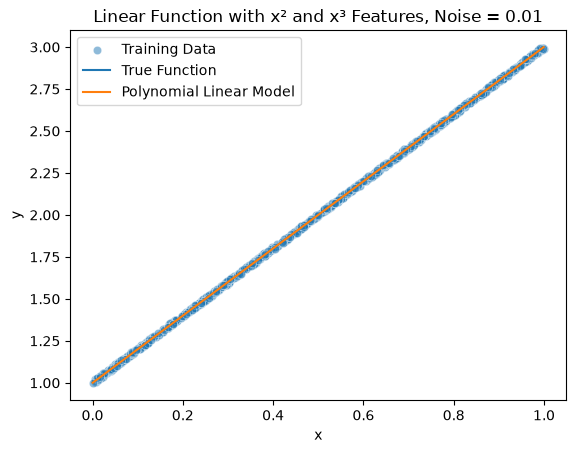

Linear Function | Noise = 0.1
Weights: [ 0.99646512  2.05095521 -0.15828244  0.12164481]
Train RMSE: 0.059408479352604064
Test RMSE: 0.05729452459405978


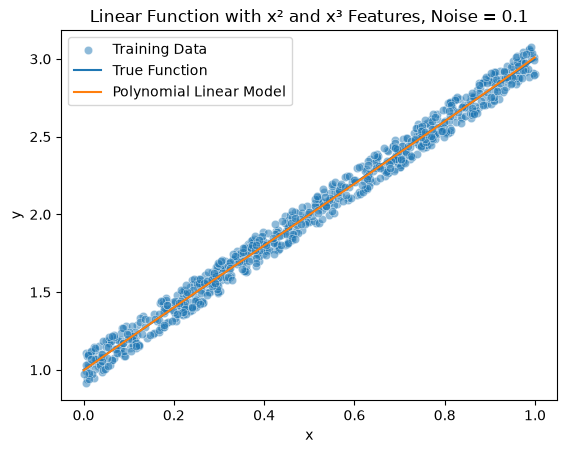

Cubic Function | Noise = 0.01
Weights: [-3.53487549e-04  1.00509552e+00 -1.01582824e+00  5.12164481e-01]
Train RMSE: 0.005940847935260406
Test RMSE: 0.005729452459404295


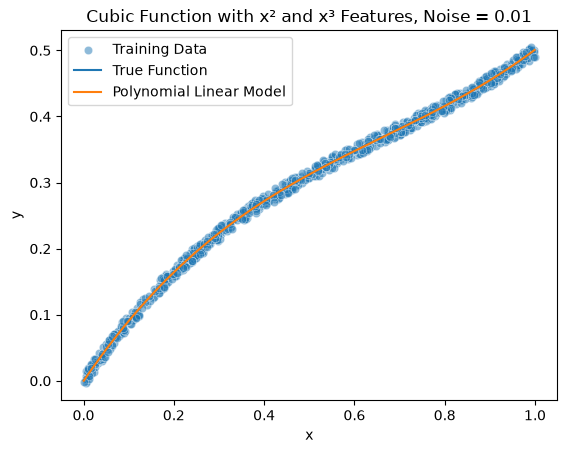

Cubic Function | Noise = 0.1
Weights: [-0.00353488  1.05095521 -1.15828244  0.62164481]
Train RMSE: 0.05940847935260407
Test RMSE: 0.05729452459406258


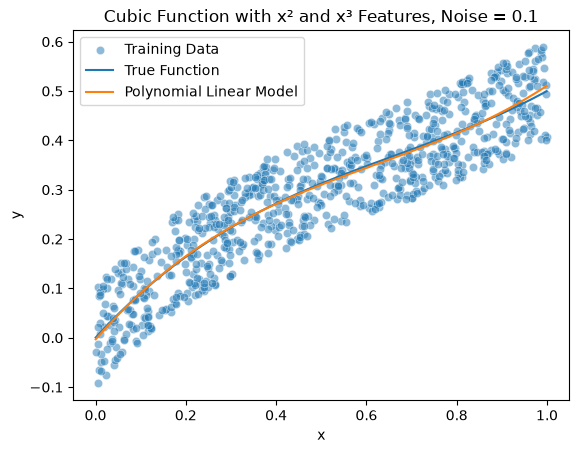

In [67]:
# Save learned models separately
q4_models = {}

# Save complete Question 4 experiment results
q4_results = {}

for function_name, true_function, epsilon in experiments:

    # Generate the dataset with x^2 and x^3 features
    dataset = generate_noisy_dataset(
        feature_functions=[
            lambda x: x**2,
            lambda x: x**3
        ],
        true_function=true_function,
        x_range=(0, 1),
        n_samples=1000,
        epsilon=epsilon,
        seed=20
    )

    # Split into 80% training and 20% testing
    train_data, test_data = train_test_split(
        dataset,
        test_size=0.2,
        random_state=42
    )

     # Train the linear regression model
    beta = linear_fit(train_data)

    # Save the learned model weights
    q4_models[(function_name, epsilon)] = beta.copy()

    # Predict on the train_data
    train_predictions = linear_predict(beta, train_data)

    train_rmse = linear_evaluate(
    train_predictions,
    train_data.iloc[:, -1]
    )

    
    #Predict on test data
    test_predictions = linear_predict(beta, test_data)

    test_rmse = linear_evaluate(
    test_predictions,
    test_data.iloc[:, -1]
    )
    
    # Save all results for this experiment
    q4_results[(function_name, epsilon)] = {
    "dataset": dataset.copy(),
    "train_data": train_data.copy(),
    "test_data": test_data.copy(),
    "beta": beta.copy(),
    "train_predictions": train_predictions.copy(),
    "test_predictions": test_predictions.copy(),
    "train_rmse": train_rmse,
    "test_rmse": test_rmse
}
    # Print results
    print(f"{function_name} Function | Noise = {epsilon}")
    print("Weights:", beta)
    print("Train RMSE:", train_rmse)
    print("Test RMSE:", test_rmse)

    # Sort training x-values for plotting
    x_plot = np.sort(
        train_data["x"].to_numpy()
    )

    # True function values
    y_true_plot = true_function(x_plot)

    # Full learned polynomial linear model
    y_model_plot = (
        beta[0]
        + beta[1] * x_plot
        + beta[2] * x_plot**2
        + beta[3] * x_plot**3
    )

    # Plot noisy training data
    sns.scatterplot(
        data=train_data,
        x="x",
        y="y",
        label="Training Data",
        alpha=0.5
    )

    # Plot true function
    plt.plot(
        x_plot,
        y_true_plot,
        label="True Function"
    )

    # Plot learned polynomial linear model
    plt.plot(
        x_plot,
        y_model_plot,
        label="Polynomial Linear Model"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(
        f"{function_name} Function with x² and x³ Features, Noise = {epsilon}"
    )
    plt.legend()
    plt.show()

**Interpretation of the linear function plots with x, \(x^2\) and \(x^3\) features:-** 
The light blue points represent the noisy training data generated from the true linear function \(f(x)=2x+1\). The blue line represents the true function without noise, while the orange line represents the polynomial linear model learned using the features \(x\), \(x^2\), and \(x^3\). For both noise levels, the orange line almost overlaps with the blue true-function line, showing that the added polynomial features do not significantly change the fit for this already linear relationship. When the noise increases from 0.01 to 0.1, the training points become more spread out and the RMSE increases, but the model still learns the underlying linear trend very well. The coefficients of the \(x^2\) and \(x^3\) terms remain relatively small compared with the coefficient of \(x\), which suggests that these extra features are not very important for the linear true function.

**Interpretation of the cubic function plots with x, \(x^2\) and \(x^3\) features:** 
The light blue points represent the noisy training data generated from the cubic true function. The blue line shows the true cubic function, while the orange line shows the learned model using \(x\), \(x^2\), and \(x^3\) as input features. With noise = 0.01, the learned model almost completely overlaps the true function, and the learned coefficients are very close to the coefficients of the original cubic function. When the noise increases to 0.1, the training points become more spread out and the RMSE increases, but the learned model still follows the true curved relationship closely. This shows that adding \(x^2\) and \(x^3\) allows the linear regression model to represent the cubic relationship much better than when only \(x\) was used.

### Question 5

In [13]:
q3_models

{('Linear', 0.01): array([0.99985728, 2.00021643]),
 ('Linear', 0.1): array([0.99857284, 2.00216426]),
 ('Cubic', 0.01): array([0.06644583, 0.44987209]),
 ('Cubic', 0.1): array([0.06516139, 0.45181992])}

In [14]:
q4_models

{('Linear', 0.01): array([ 0.99964651,  2.00509552, -0.01582824,  0.01216448]),
 ('Linear', 0.1): array([ 0.99646512,  2.05095521, -0.15828244,  0.12164481]),
 ('Cubic',
  0.01): array([-3.53487549e-04,  1.00509552e+00, -1.01582824e+00,  5.12164481e-01]),
 ('Cubic', 0.1): array([-0.00353488,  1.05095521, -1.15828244,  0.62164481])}

In [15]:
x_new = 10

for (function_name, epsilon), beta in q3_models.items():

    if function_name == "Linear":
        true_y = linear_function(x_new)
    else:
        true_y = cubic_function(x_new)

    point = pd.DataFrame({
        "x": [x_new],
        "y": [true_y]
    })

    prediction = linear_predict(beta, point)

    error = linear_evaluate(
        prediction,
        np.array([true_y])
    )

    print(f"{function_name} | Noise = {epsilon}")
    print("True y:", true_y)
    print("Predicted y:", prediction[0])
    print("Error:", error)
    print()

Linear | Noise = 0.01
True y: 21
Predicted y: 21.002021544728418
Error: 0.002021544728417979

Linear | Noise = 0.1
True y: 21
Predicted y: 21.02021544728417
Error: 0.02021544728416913

Cubic | Noise = 0.01
True y: 410.0
Predicted y: 4.565166738450367
Error: 405.4348332615496

Cubic | Noise = 0.1
True y: 410.0
Predicted y: 4.583360641006122
Error: 405.4166393589939



In [17]:
q5_rows = []

x_new = 10

# Results using only x
for (function_name, epsilon), beta in q3_models.items():

    if function_name == "Linear":
        true_y = linear_function(x_new)
    else:
        true_y = cubic_function(x_new)

    point = pd.DataFrame({
        "x": [x_new],
        "y": [true_y]
    })

    prediction = linear_predict(beta, point)

    error = linear_evaluate(
        prediction,
        np.array([true_y])
    )

    q5_rows.append({
        "Features": "x",
        "Function": function_name,
        "Noise": epsilon,
        "True y": true_y,
        "Predicted y": prediction[0],
        "Error": error
    })


# Results using x, x^2, and x^3
for (function_name, epsilon), beta in q4_models.items():

    if function_name == "Linear":
        true_y = linear_function(x_new)
    else:
        true_y = cubic_function(x_new)

    point = pd.DataFrame({
        "x": [x_new],
        "f_1(x)": [x_new**2],
        "f_2(x)": [x_new**3],
        "y": [true_y]
    })

    prediction = linear_predict(beta, point)

    error = linear_evaluate(
        prediction,
        np.array([true_y])
    )

    q5_rows.append({
        "Features": "x, x^2, x^3",
        "Function": function_name,
        "Noise": epsilon,
        "True y": true_y,
        "Predicted y": prediction[0],
        "Error": error
    })


q5_results = pd.DataFrame(q5_rows)

q5_results

,Features,Function,Noise,True y,Predicted y,Error
0,x,Linear,0.01,21.0,21.002022,0.002022
1,x,Linear,0.10,21.0,21.020215,0.020215
2,x,Cubic,0.01,410.0,4.565167,405.434833
3,x,Cubic,0.10,410.0,4.583361,405.416639
4,"x, x^2, x^3",Linear,0.01,21.0,31.632258,10.632258
5,"x, x^2, x^3",Linear,0.10,21.0,127.322581,106.322581
6,"x, x^2, x^3",Cubic,0.01,410.0,420.632258,10.632258
7,"x, x^2, x^3",Cubic,0.10,410.0,516.322581,106.322581


In [20]:
print("Question 3 Models where only feature is x")

for (function_name, epsilon), beta in q3_models.items():
    print(f"{function_name} | Noise = {epsilon}")
    print("Coefficients:", beta)
    print()

Question 3 Models where only feature is x
Linear | Noise = 0.01
Coefficients: [0.99985728 2.00021643]

Linear | Noise = 0.1
Coefficients: [0.99857284 2.00216426]

Cubic | Noise = 0.01
Coefficients: [0.06644583 0.44987209]

Cubic | Noise = 0.1
Coefficients: [0.06516139 0.45181992]



In [22]:
print("Question 4 Models where features are x,x^2 and x^3")

for (function_name, epsilon), beta in q4_models.items():
    print(f"{function_name} | Noise = {epsilon}")
    print("Coefficients:", beta)
    print()

Question 4 Models where features are x,x^2 and x^3
Linear | Noise = 0.01
Coefficients: [ 0.99964651  2.00509552 -0.01582824  0.01216448]

Linear | Noise = 0.1
Coefficients: [ 0.99646512  2.05095521 -0.15828244  0.12164481]

Cubic | Noise = 0.01
Coefficients: [-3.53487549e-04  1.00509552e+00 -1.01582824e+00  5.12164481e-01]

Cubic | Noise = 0.1
Coefficients: [-0.00353488  1.05095521 -1.15828244  0.62164481]



#### Question 7 :- 


In [24]:
# Question 7 base dataset


q7_data = generate_noisy_dataset(
    feature_functions=[],
    true_function=cubic_function,
    x_range=(0, 1),
    n_samples=1000,
    epsilon=0.1,
    seed=14
)
q7_train, q7_test = train_test_split(
    q7_data,
    test_size=0.2,
    random_state=14
)

In [25]:
degrees = []
train_rmse_values = []
test_rmse_values = []

In [26]:
for degree in range(1, 11):

    # Make copies so the original train/test data are unchanged
    train_degree = q7_train.copy()
    test_degree = q7_test.copy()

    # Add x^2, x^3, ... up to the current degree
    for power in range(2, degree + 1):

        train_degree.insert(
            len(train_degree.columns) - 1, #this adds the new column just before the last column in train data
            f"x^{power}",
            train_degree["x"] ** power
        )

        test_degree.insert(
            len(test_degree.columns) - 1, ## this adds the new column just before the last column in test data
            f"x^{power}",
            test_degree["x"] ** power
        )

    # Fit model
    beta = linear_fit(train_degree)

    # Predict on training data
    train_predictions = linear_predict(
        beta,
        train_degree
    )

    # Predict on test data
    test_predictions = linear_predict(
        beta,
        test_degree
    )

    # Calculate training RMSE
    train_rmse = linear_evaluate(
        train_predictions,
        train_degree.iloc[:, -1]
    )

    # Calculate test RMSE
    test_rmse = linear_evaluate(
        test_predictions,
        test_degree.iloc[:, -1]
    )

    # Store results
    degrees.append(degree)
    train_rmse_values.append(train_rmse)
    test_rmse_values.append(test_rmse)

In [27]:
for i in range(len(degrees)):
    print("For Degree",degrees[i], " Train Rmse is:- ", train_rmse_values[i], "and Test Rmse is:- ", test_rmse_values[i])


For Degree 1  Train Rmse is:-  0.061946695714966485 and Test Rmse is:-  0.06296232059171071
For Degree 2  Train Rmse is:-  0.05945625786537929 and Test Rmse is:-  0.059642117230614515
For Degree 3  Train Rmse is:-  0.05777052793276458 and Test Rmse is:-  0.05811871793570021
For Degree 4  Train Rmse is:-  0.05772009583605107 and Test Rmse is:-  0.05792057553152844
For Degree 5  Train Rmse is:-  0.057703482174950985 and Test Rmse is:-  0.05798702366150031
For Degree 6  Train Rmse is:-  0.05770029190666992 and Test Rmse is:-  0.057988267185633005
For Degree 7  Train Rmse is:-  0.05755659291285605 and Test Rmse is:-  0.05877208958304156
For Degree 8  Train Rmse is:-  0.05749519680670184 and Test Rmse is:-  0.05896330234869327
For Degree 9  Train Rmse is:-  0.05747428887916121 and Test Rmse is:-  0.05894387894308563
For Degree 10  Train Rmse is:-  0.05741992650101582 and Test Rmse is:-  0.05886264849089873


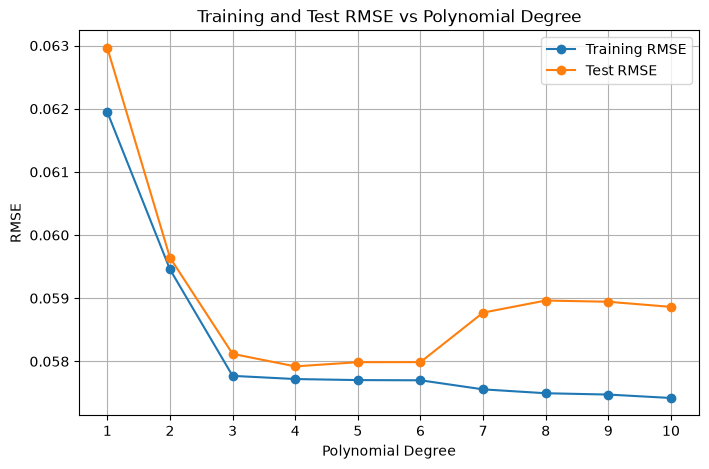

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(degrees, train_rmse_values, marker="o", label="Training RMSE")
plt.plot(degrees, test_rmse_values, marker="o", label="Test RMSE")

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Training and Test RMSE vs Polynomial Degree")
plt.xticks(degrees)
plt.legend()
plt.grid(True)
plt.show()

**Interpretation:-**:-
As the polynomial degree increases from 1 to around 3 or 4, both the training and test RMSE decrease. This happens because adding higher-order polynomial terms allows the model to represent the cubic relationship in the data more accurately.

After this point, the training RMSE continues to decrease slightly, but the test RMSE begins to increase. This suggests that the higher-degree models start fitting the training data and its noise more closely, while their performance on unseen test data becomes worse.

Since the true function is cubic, a degree around 3 is already enough to represent the underlying relationship. Adding much higher-degree terms does not add useful information and can lead to overfitting.

### Question 8 :- Decision Tree

In [53]:
class TreeNode:
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):

        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value   # Only set for leaf nodes

    def is_leaf(self):
        return self.value is not None


def variance(y):
    if len(y) == 0:
        return 0.0

    y_mean = np.mean(y)

    return np.sum((y - y_mean) ** 2) / len(y)


def candidate_thresholds(column):
    # Get sorted unique values
    values = np.unique(column)

    # Midpoints between consecutive values
    return [
        (values[i] + values[i + 1]) / 2
        for i in range(len(values) - 1)
    ]


class RegressionTree:

    def __init__(self):
        self.root = None
        self.min_records = None
        self.feature_names = None
        self.training_data = None


    def fit(self, dataset, min_records):

        # Save information for later use
        self.min_records = min_records
        self.training_data = dataset.copy()

        # Last column is y
        X = dataset.iloc[:, :-1].to_numpy()
        y = dataset.iloc[:, -1].to_numpy()

        self.feature_names = list(dataset.columns[:-1])

        # Build tree recursively
        self.root = self._grow(X, y)

        return self


    def _leaf_value(self, y):

        # Regression leaf predicts the mean y value
        return np.mean(y)


    def _grow(self, X, y):

        n, m = X.shape

        # Stop splitting if there are fewer than min_records
        if len(y) < self.min_records:
            return TreeNode(
                value=self._leaf_value(y)
            )

        # Stop if all target values are the same
        if len(np.unique(y)) == 1:
            return TreeNode(
                value=self._leaf_value(y)
            )

        parent_impurity = variance(y)

        best_gain = 0.0
        best_feature = None
        best_threshold = None


        # Try every input feature
        for feature in range(m):

            # Try every possible threshold for this feature
            for threshold in candidate_thresholds(X[:, feature]):

                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                # Skip invalid splits
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                # Weighted variance after the split
                weighted_child_impurity = (
                    (len(y_left) / len(y)) * variance(y_left)
                    +
                    (len(y_right) / len(y)) * variance(y_right)
                )

                # Variance reduction
                gain = (
                    parent_impurity
                    - weighted_child_impurity
                )

                # Keep the best split found
                if gain > best_gain:

                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold


        # If no useful split was found, create a leaf
        if best_feature is None:

            return TreeNode(
                value=self._leaf_value(y)
            )


        # Split using the best feature and threshold
        left_mask = (
            X[:, best_feature]
            <= best_threshold
        )

        # Recursively grow left subtree
        left = self._grow(
            X[left_mask],
            y[left_mask]
        )

        # Recursively grow right subtree
        right = self._grow(
            X[~left_mask],
            y[~left_mask]
        )

        return TreeNode(
            feature=best_feature,
            threshold=best_threshold,
            left=left,
            right=right
        )


    def _predict_one(self, x, node):

        # If leaf, return its prediction
        if node.is_leaf():
            return node.value

        # Follow the appropriate branch
        if x[node.feature] <= node.threshold:
            return self._predict_one(
                x,
                node.left
            )

        else:
            return self._predict_one(
                x,
                node.right
            )


    def predict(self, X):

        # Allow a DataFrame to be passed directly
        if isinstance(X, pd.DataFrame):

            # If y is included, remove it
            if "y" in X.columns:
                X = X.iloc[:, :-1]

            X = X.to_numpy()

        return np.array([
            self._predict_one(x, self.root)
            for x in X
        ])


    def _collect_split_points(self, node, split_points):

        if node is None or node.is_leaf():
            return

        split_points.append(
            (node.feature, node.threshold)
        )

        self._collect_split_points(
            node.left,
            split_points
        )

        self._collect_split_points(
            node.right,
            split_points
        )
    def visualize(self, X_plot):

        y_pred = self.predict(X_plot)

        plt.plot(
            X_plot[:, 0],
            y_pred,
            label="Tree Prediction"
        )

        split_points = []

        self._collect_split_points(
            self.root,
            split_points
        )

        for feature, threshold in split_points:

            if feature == 0:
                plt.axvline(
                    x=threshold,
                    linestyle="--",
                    alpha=0.4
                )

In [68]:
# Save fitted trees
q9_trees = {}

# Save results
q9_results = []

min_records_values = [1000, 50, 1]

q9_datasets = [
    ("Linear", 0.01, "(x, y)", q3_results[("Linear", 0.01)]),
    ("Linear", 0.1, "(x, y)", q3_results[("Linear", 0.1)]),
    ("Cubic", 0.01, "(x, y)", q3_results[("Cubic", 0.01)]),
    ("Cubic", 0.1, "(x, y)", q3_results[("Cubic", 0.1)]),

    ("Linear", 0.01, "(x, x^2, x^3, y)", q4_results[("Linear", 0.01)]),
    ("Linear", 0.1, "(x, x^2, x^3, y)", q4_results[("Linear", 0.1)]),
    ("Cubic", 0.01, "(x, x^2, x^3, y)", q4_results[("Cubic", 0.01)]),
    ("Cubic", 0.1, "(x, x^2, x^3, y)", q4_results[("Cubic", 0.1)])
]


for function_name, epsilon, schema, saved_data in q9_datasets:

    train_data = saved_data["train_data"]
    test_data = saved_data["test_data"]

    for min_records in min_records_values:

        tree = RegressionTree()

        tree.fit(
            train_data,
            min_records=min_records
        )

        # Save fitted tree
        q9_trees[
            (function_name, epsilon, schema, min_records)
        ] = tree

        # Predict on train data
        train_predictions = tree.predict(train_data)

        # Calculate train RMSE
        train_rmse = linear_evaluate(
            train_predictions,
            train_data.iloc[:, -1]
        )

        # Predict on test data
        test_predictions = tree.predict(test_data)

        # Calculate test RMSE
        test_rmse = linear_evaluate(
            test_predictions,
            test_data.iloc[:, -1]
        )

        # Save results
        q9_results.append({
            "Function": function_name,
            "Noise": epsilon,
            "Schema": schema,
            "Min Records": min_records,
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse
        })

        print(
            f"{function_name} | Noise = {epsilon} | "
            f"Schema = {schema} | "
            f"min_records = {min_records} | "
            f"Train RMSE = {train_rmse} | "
            f"Test RMSE = {test_rmse}"
        )

Linear | Noise = 0.01 | Schema = (x, y) | min_records = 1000 | Train RMSE = 0.5824036863775153 | Test RMSE = 0.6150731946293789
Linear | Noise = 0.01 | Schema = (x, y) | min_records = 50 | Train RMSE = 0.02452462849833747 | Test RMSE = 0.028348595057153814
Linear | Noise = 0.01 | Schema = (x, y) | min_records = 1 | Train RMSE = 0.0 | Test RMSE = 0.008156754692192722
Linear | Noise = 0.1 | Schema = (x, y) | min_records = 1000 | Train RMSE = 0.5859670436440229 | Test RMSE = 0.6197034094335345
Linear | Noise = 0.1 | Schema = (x, y) | min_records = 50 | Train RMSE = 0.057516467870737005 | Test RMSE = 0.06322319291175066
Linear | Noise = 0.1 | Schema = (x, y) | min_records = 1 | Train RMSE = 0.0 | Test RMSE = 0.08048280044547053
Cubic | Noise = 0.01 | Schema = (x, y) | min_records = 1000 | Train RMSE = 0.13283736086725448 | Test RMSE = 0.14156996410545927
Cubic | Noise = 0.01 | Schema = (x, y) | min_records = 50 | Train RMSE = 0.0077220172605280205 | Test RMSE = 0.008486488482517566
Cubic |

In [73]:
q9_results_df = pd.DataFrame(q9_results)
q9_results_df

,Function,Noise,Schema,Min Records,Train RMSE,Test RMSE
0,Linear,0.01,"(x, y)",1000,0.582404,0.615073
1,Linear,0.01,"(x, y)",50,0.024525,0.028349
2,Linear,0.01,"(x, y)",1,0.000000,0.008157
3,Linear,0.10,"(x, y)",1000,0.585967,0.619703
4,Linear,0.10,"(x, y)",50,0.057516,0.063223
5,Linear,0.10,"(x, y)",1,0.000000,0.080483
6,Cubic,0.01,"(x, y)",1000,0.132837,0.141570
7,Cubic,0.01,"(x, y)",50,0.007722,0.008486
8,Cubic,0.01,"(x, y)",1,0.000000,0.008044
9,Cubic,0.10,"(x, y)",1000,0.145879,0.153494


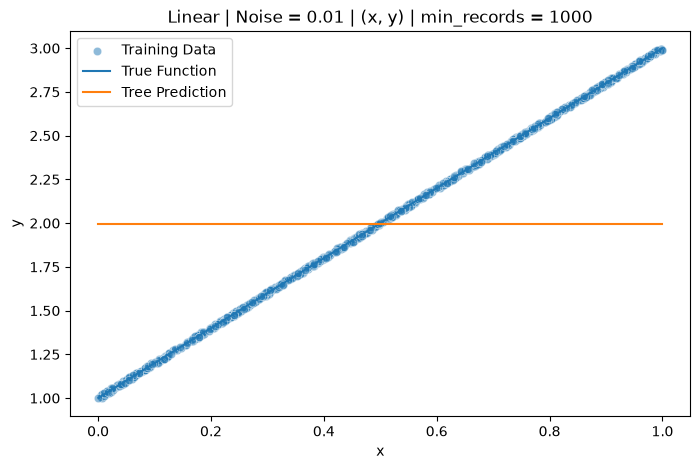

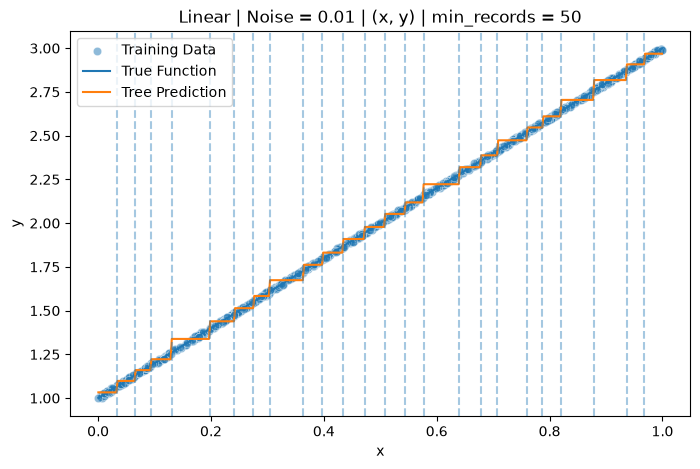

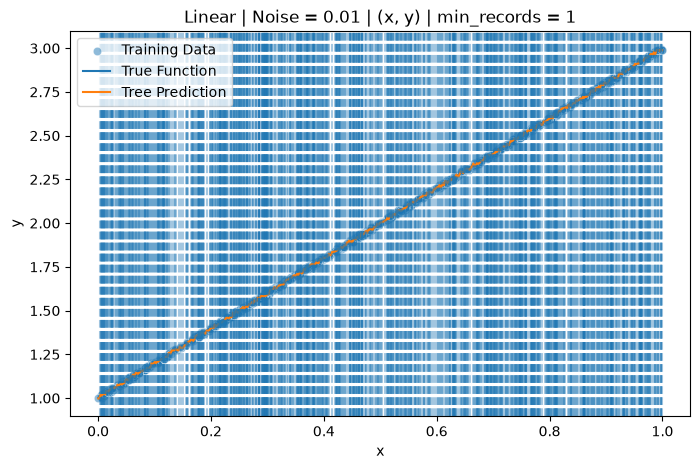

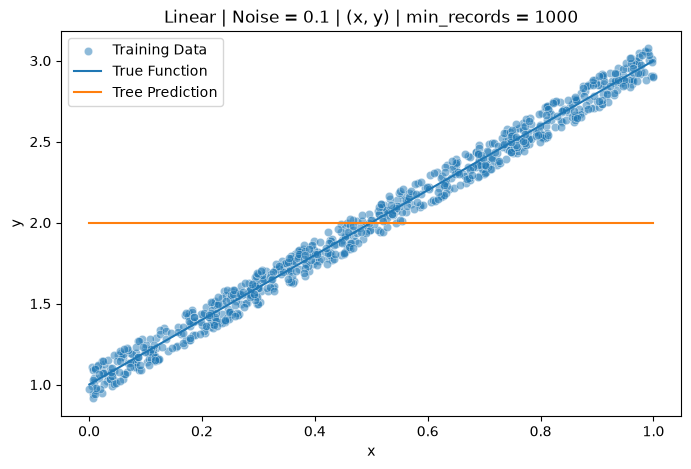

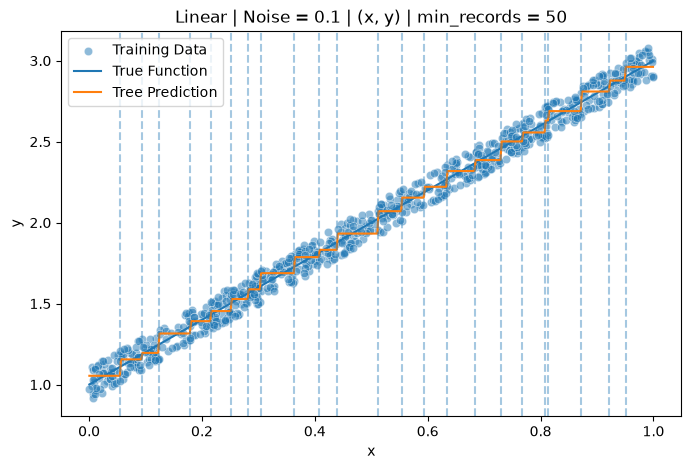

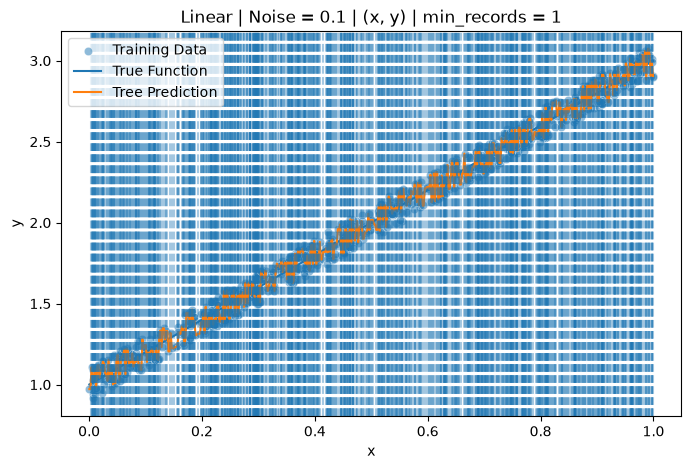

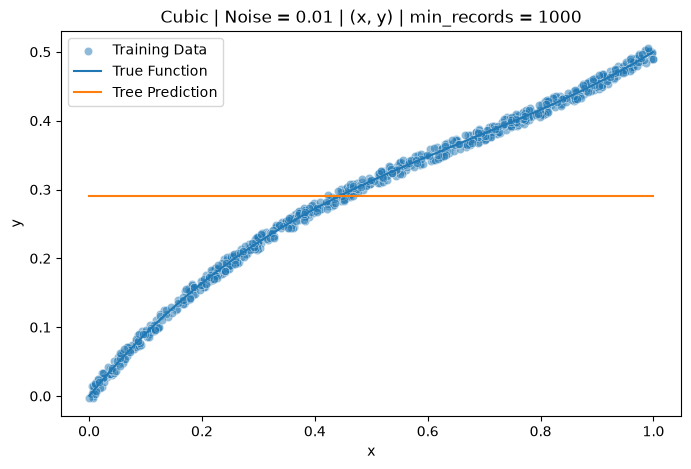

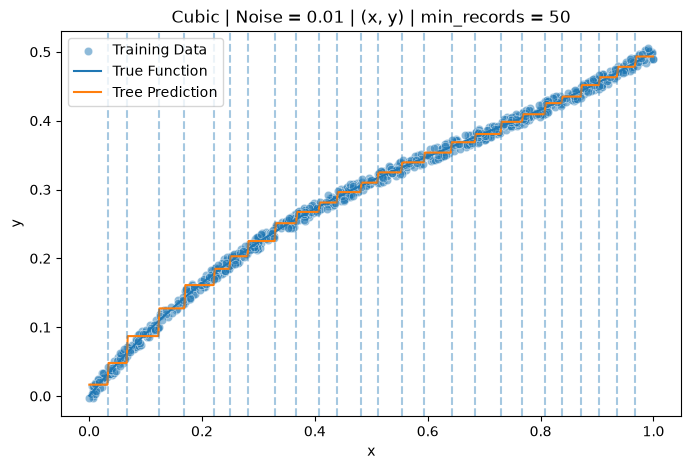

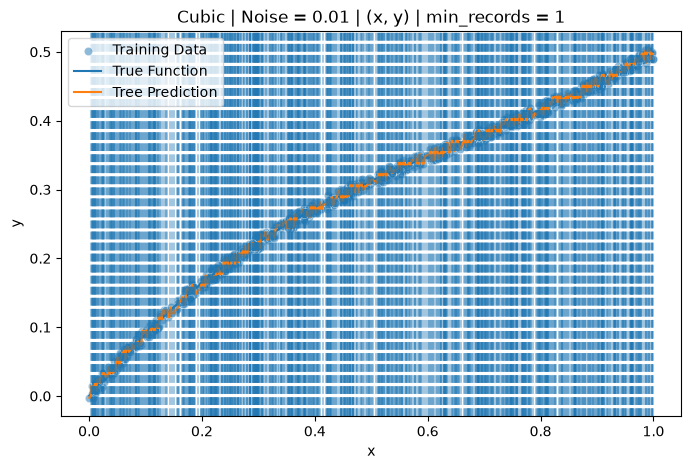

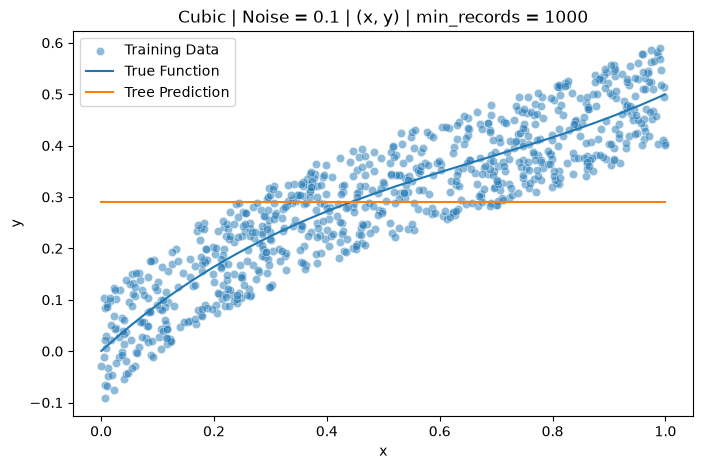

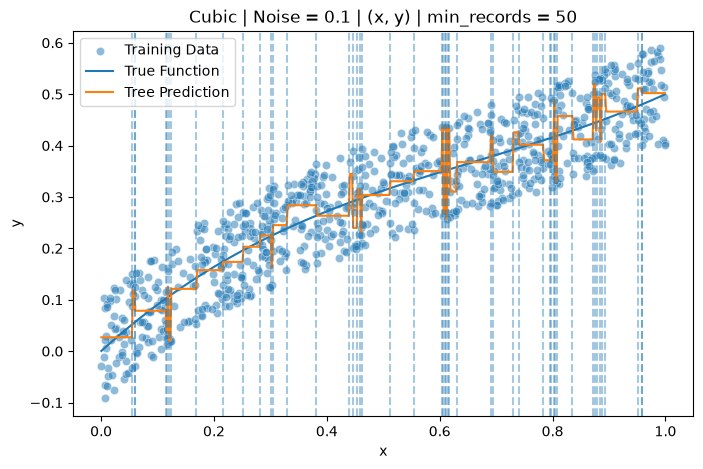

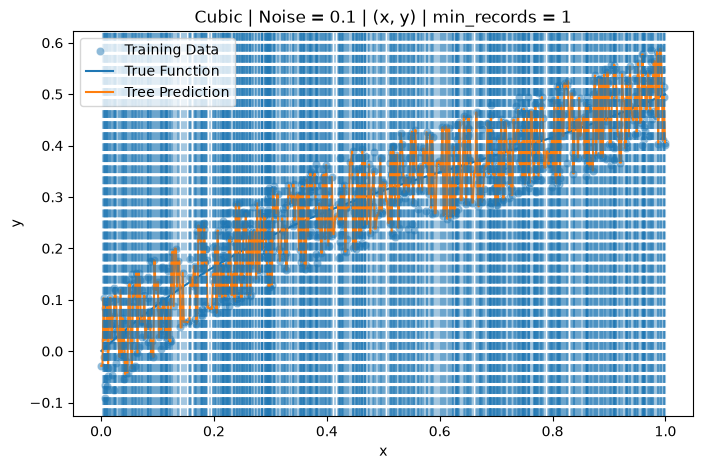

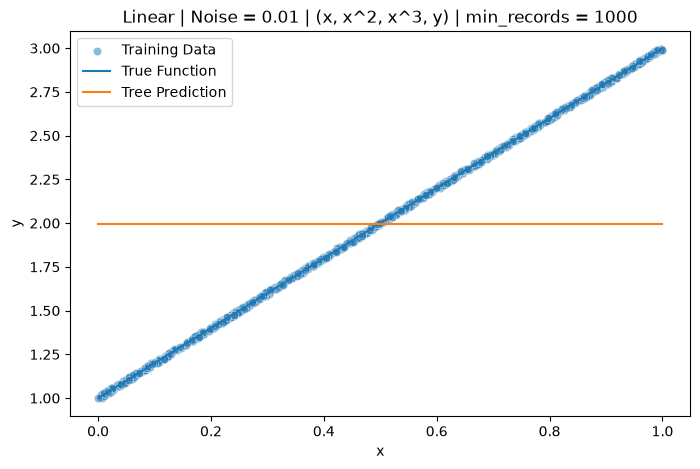

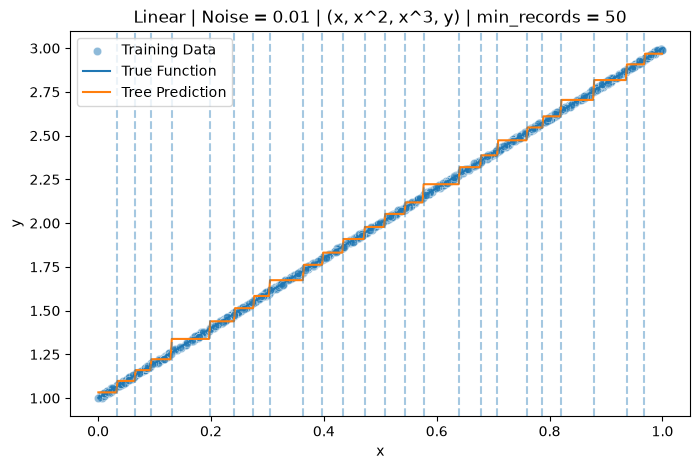

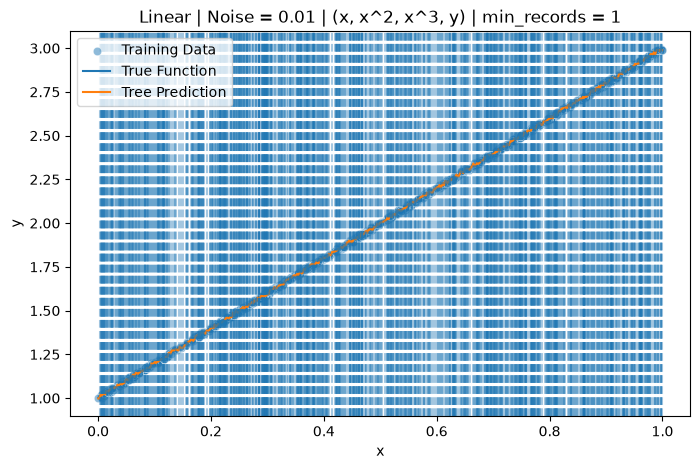

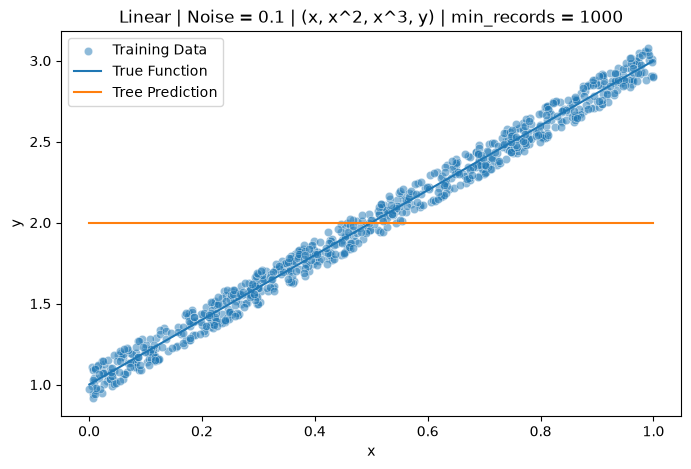

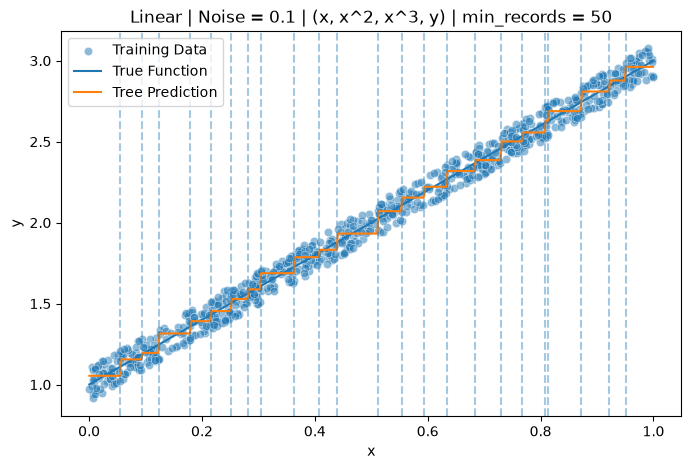

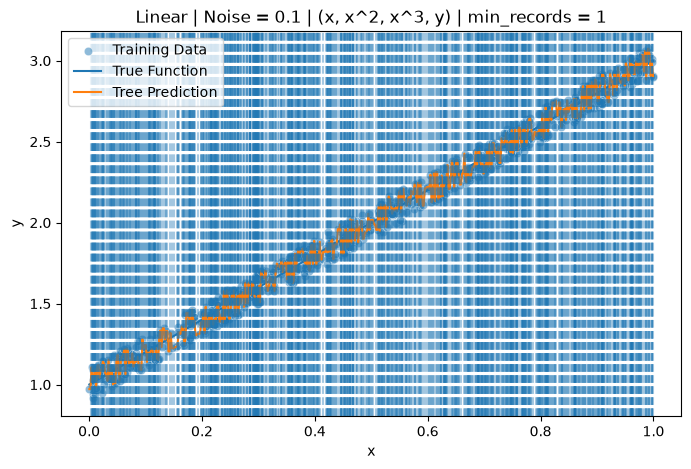

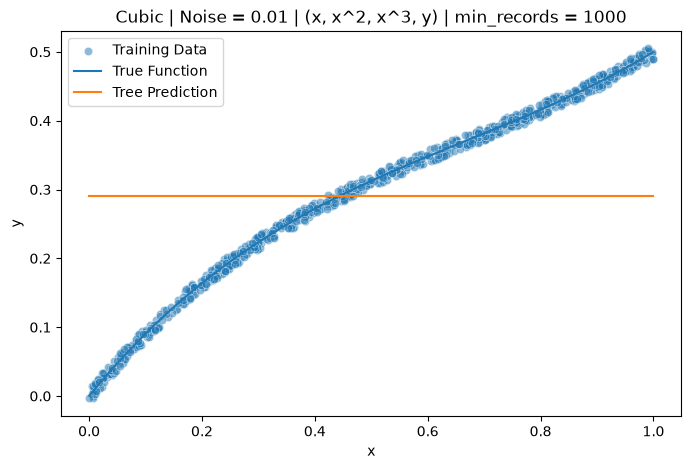

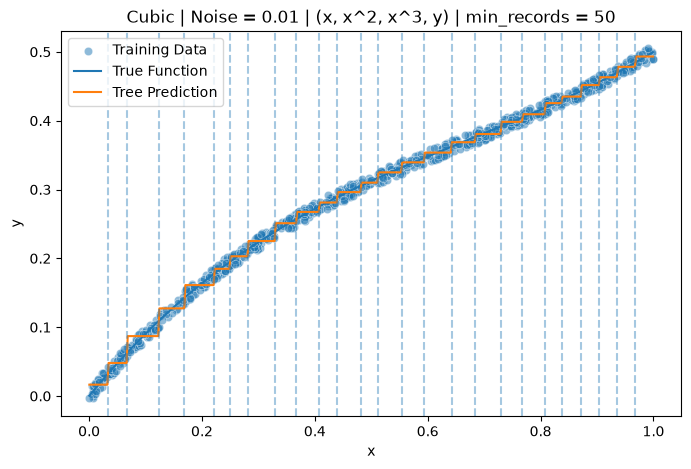

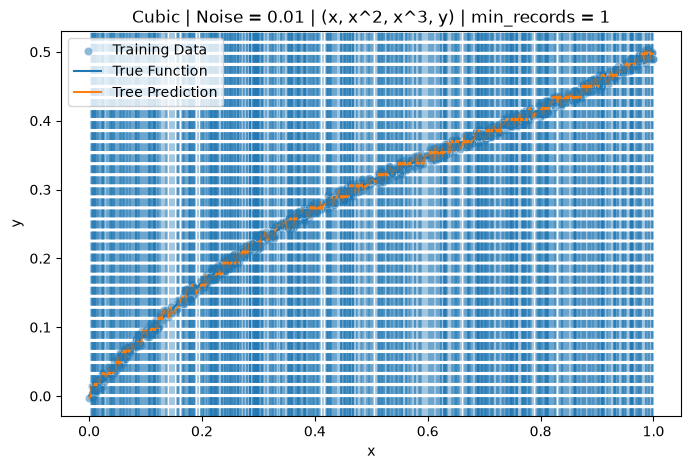

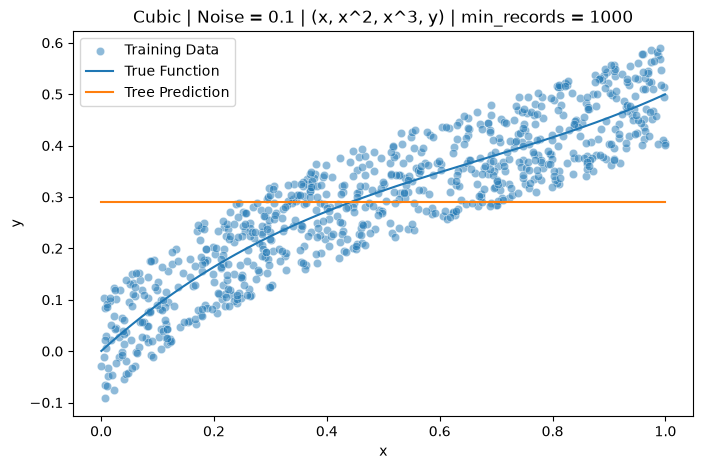

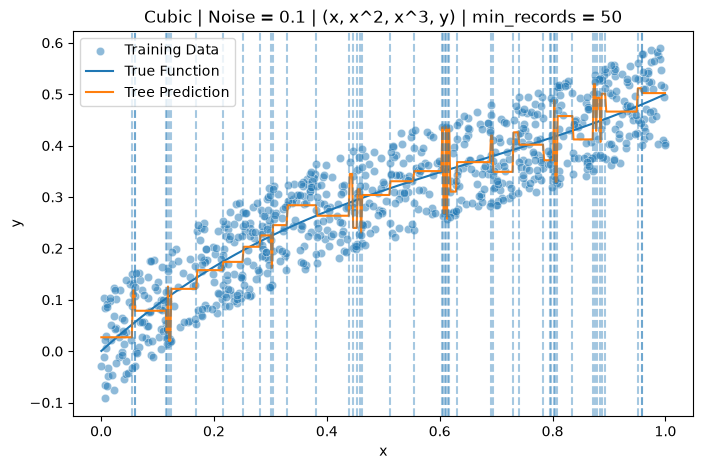

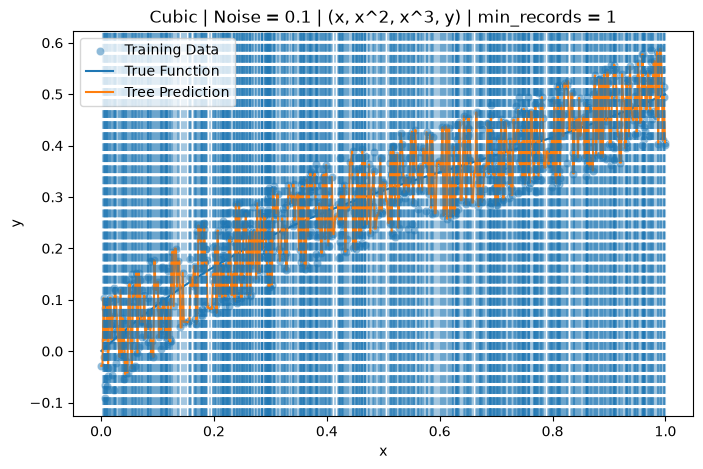

In [74]:
for function_name, epsilon, schema, saved_data in q9_datasets:

    train_data = saved_data["train_data"]

    if function_name == "Linear":
        true_function = linear_function
    else:
        true_function = cubic_function

    # x-values for plotting
    x_plot = np.linspace(
        train_data["x"].min(),
        train_data["x"].max(),
        500
    )

    # True function
    y_true_plot = true_function(x_plot)

    for min_records in min_records_values:

        tree = q9_trees[
            (function_name, epsilon, schema, min_records)
        ]

        plt.figure(figsize=(8, 5))

        # Plot training data
        sns.scatterplot(
            data=train_data,
            x="x",
            y="y",
            label="Training Data",
            alpha=0.5
        )

        # Plot true function
        plt.plot(
            x_plot,
            y_true_plot,
            label="True Function"
        )

        # Build the correct input for tree prediction
        if schema == "(x, y)":

            X_plot = x_plot.reshape(-1, 1)

        else:

            X_plot = np.column_stack([
                x_plot,
                x_plot**2,
                x_plot**3
            ])

        # Plot tree prediction and split points
        tree.visualize(X_plot)

        plt.xlabel("x")
        plt.ylabel("y")

        plt.title(
            f"{function_name} | Noise = {epsilon} | "
            f"{schema} | min_records = {min_records}"
        )

        plt.legend()
        plt.show()

## Question 10 

In [75]:
q9_results

[{'Function': 'Linear',
  'Noise': 0.01,
  'Schema': '(x, y)',
  'Min Records': 1000,
  'Train RMSE': np.float64(0.5824036863775153),
  'Test RMSE': np.float64(0.6150731946293789)},
 {'Function': 'Linear',
  'Noise': 0.01,
  'Schema': '(x, y)',
  'Min Records': 50,
  'Train RMSE': np.float64(0.02452462849833747),
  'Test RMSE': np.float64(0.028348595057153814)},
 {'Function': 'Linear',
  'Noise': 0.01,
  'Schema': '(x, y)',
  'Min Records': 1,
  'Train RMSE': np.float64(0.0),
  'Test RMSE': np.float64(0.008156754692192722)},
 {'Function': 'Linear',
  'Noise': 0.1,
  'Schema': '(x, y)',
  'Min Records': 1000,
  'Train RMSE': np.float64(0.5859670436440229),
  'Test RMSE': np.float64(0.6197034094335345)},
 {'Function': 'Linear',
  'Noise': 0.1,
  'Schema': '(x, y)',
  'Min Records': 50,
  'Train RMSE': np.float64(0.057516467870737005),
  'Test RMSE': np.float64(0.06322319291175066)},
 {'Function': 'Linear',
  'Noise': 0.1,
  'Schema': '(x, y)',
  'Min Records': 1,
  'Train RMSE': np.float

In [76]:
# This function counts the number of nodes in the tree
def count_nodes(node):
    if node is None:
        return 0

    return 1 + count_nodes(node.left) + count_nodes(node.right)


# This counts number of records in leaf
def count_leaf_records(node, X):
    if node.is_leaf():
        return [len(X)]

    left_mask = X[:, node.feature] <= node.threshold

    left_counts = count_leaf_records(
        node.left,
        X[left_mask]
    )

    right_counts = count_leaf_records(
        node.right,
        X[~left_mask]
    )

    return left_counts + right_counts

In [77]:
q10_rows = []

for _, row in q9_results_df.iterrows():

    function_name = row["Function"]
    epsilon = row["Noise"]
    schema = row["Schema"]
    min_records = row["Min Records"]

    # Tree RMSE values from Question 9
    tree_train_rmse = row["Train RMSE"]
    tree_test_rmse = row["Test RMSE"]

    # Corresponding linear regression results
    if schema == "(x, y)":

        linear_train_rmse = q3_results[
            (function_name, epsilon)
        ]["train_rmse"]

        linear_test_rmse = q3_results[
            (function_name, epsilon)
        ]["test_rmse"]

        train_data = q3_results[
            (function_name, epsilon)
        ]["train_data"]

    else:

        linear_train_rmse = q4_results[
            (function_name, epsilon)
        ]["train_rmse"]

        linear_test_rmse = q4_results[
            (function_name, epsilon)
        ]["test_rmse"]

        train_data = q4_results[
            (function_name, epsilon)
        ]["train_data"]


    # Retrieve fitted tree
    tree = q9_trees[
        (function_name, epsilon, schema, min_records)
    ]


    # Count total nodes
    total_nodes = count_nodes(tree.root)


    # Count records in each leaf
    X_train = train_data.iloc[:, :-1].to_numpy()

    leaf_records = count_leaf_records(
        tree.root,
        X_train
    )


    # Number of leaf nodes
    number_of_leaves = len(leaf_records)


    # Save Question 10 results
    q10_rows.append({
        "Function": function_name,
        "Noise": epsilon,
        "Schema": schema,
        "Min Records": min_records,

        "Linear Train RMSE": linear_train_rmse,
        "Linear Test RMSE": linear_test_rmse,

        "Tree Train RMSE": tree_train_rmse,
        "Tree Test RMSE": tree_test_rmse,

        "Total Nodes": total_nodes,
        "Number of Leaves": number_of_leaves,
        "Records per Leaf": leaf_records
    })


q10_results = pd.DataFrame(q10_rows)

q10_results

,Function,Noise,Schema,Min Records,Linear Train RMSE,Linear Test RMSE,Tree Train RMSE,Tree Test RMSE,Total Nodes,Number of Leaves,Records per Leaf
0,Linear,0.01,"(x, y)",1000,0.005948,0.005723,0.582404,0.615073,1,1,[800]
1,Linear,0.01,"(x, y)",50,0.005948,0.005723,0.024525,0.028349,49,25,"[29, 28, 23, 31, 36, 44, 32, 34, 45, 33, 26, 3..."
2,Linear,0.01,"(x, y)",1,0.005948,0.005723,0.000000,0.008157,1599,800,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,Linear,0.10,"(x, y)",1000,0.059480,0.057227,0.585967,0.619703,1,1,[800]
4,Linear,0.10,"(x, y)",50,0.059480,0.057227,0.057516,0.063223,47,24,"[47, 33, 28, 28, 27, 38, 26, 30, 45, 42, 20, 4..."
5,Linear,0.10,"(x, y)",1,0.059480,0.057227,0.000000,0.080483,1599,800,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
6,Cubic,0.01,"(x, y)",1000,0.022121,0.021417,0.132837,0.141570,1,1,[800]
7,Cubic,0.01,"(x, y)",50,0.022121,0.021417,0.007722,0.008486,51,26,"[29, 30, 49, 18, 44, 29, 28, 48, 30, 39, 20, 3..."
8,Cubic,0.01,"(x, y)",1,0.022121,0.021417,0.000000,0.008044,1599,800,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
9,Cubic,0.10,"(x, y)",1000,0.063050,0.058454,0.145879,0.153494,1,1,[800]


### Question 11

In [78]:
# True function for Question 11
def sin_function(x):
    return np.sin(2 * np.pi * x)


# Generate 200 data points
q11_dataset = generate_noisy_dataset(
    feature_functions=[],
    true_function=sin_function,
    x_range=(0, 1),
    n_samples=200,
    epsilon=0.2,
    seed=20
)


# Split into 80% training and 20% testing
q11_train_data, q11_test_data = train_test_split(
    q11_dataset,
    test_size=0.2,
    random_state=42
)

In [79]:
q11_min_records = [2, 4, 8, 16, 32, 64, 128, 256]

In [80]:
q11_results = []
q11_trees = {}

for min_records in q11_min_records:

    tree = RegressionTree()

    tree.fit(
        q11_train_data,
        min_records=min_records
    )

    # Save fitted tree
    q11_trees[min_records] = tree

    # Predict on training data
    train_predictions = tree.predict(q11_train_data)

    train_rmse = linear_evaluate(
        train_predictions,
        q11_train_data.iloc[:, -1]
    )

    # Predict on test data
    test_predictions = tree.predict(q11_test_data)

    test_rmse = linear_evaluate(
        test_predictions,
        q11_test_data.iloc[:, -1]
    )

    # Save results
    q11_results.append({
        "Min Records": min_records,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

    print(
        f"min_records = {min_records} | "
        f"Train RMSE = {train_rmse:.6f} | "
        f"Test RMSE = {test_rmse:.6f}"
    )

min_records = 2 | Train RMSE = 0.000000 | Test RMSE = 0.145890
min_records = 4 | Train RMSE = 0.050292 | Test RMSE = 0.136665
min_records = 8 | Train RMSE = 0.081702 | Test RMSE = 0.128840
min_records = 16 | Train RMSE = 0.107207 | Test RMSE = 0.137537
min_records = 32 | Train RMSE = 0.133660 | Test RMSE = 0.168499
min_records = 64 | Train RMSE = 0.174728 | Test RMSE = 0.190677
min_records = 128 | Train RMSE = 0.319643 | Test RMSE = 0.343612
min_records = 256 | Train RMSE = 0.694263 | Test RMSE = 0.762376


In [81]:
q11_results_df = pd.DataFrame(q11_results)

q11_results_df

,Min Records,Train RMSE,Test RMSE
0,2,0.000000,0.145890
1,4,0.050292,0.136665
2,8,0.081702,0.128840
3,16,0.107207,0.137537
4,32,0.133660,0.168499
5,64,0.174728,0.190677
6,128,0.319643,0.343612
7,256,0.694263,0.762376


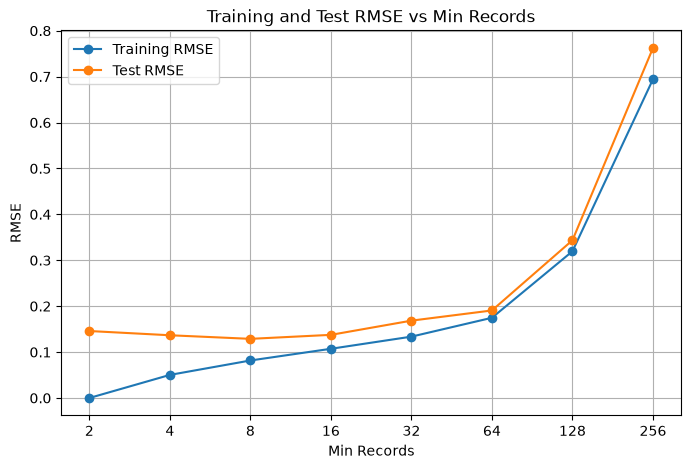

In [83]:
x_pos = np.arange(len(q11_min_records))

plt.figure(figsize=(8, 5))

plt.plot(
    x_pos,
    q11_results_df["Train RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.plot(
    x_pos,
    q11_results_df["Test RMSE"],
    marker="o",
    label="Test RMSE"
)

plt.xticks(
    x_pos,
    q11_min_records
)

plt.xlabel("Min Records")
plt.ylabel("RMSE")
plt.title("Training and Test RMSE vs Min Records")
plt.legend()
plt.grid(True)
plt.show()